# Upcoming Fight Predictions

Interactive notebook for exploring predictions on upcoming UFC cards. Loads the production model, scores upcoming fights, and presents results with visualizations.

**Prerequisites:** Run `make predict_pipeline` (or individual steps: `make load_upcoming`, `make build_upcoming_features`, `make score_upcoming`) before using this notebook.

In [2]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from warehouse.db import get_connection
from modeling.score_upcoming import score_upcoming
from modeling.calibrate import assess_calibration

REPO_ROOT = Path.cwd().parent
PRODUCTION_MODEL = REPO_ROOT / "models" / "production_model.json"
UPCOMING_FEATURES = REPO_ROOT / "models" / "upcoming" / "upcoming_features.csv"

print("Setup complete")

/home/wlodzimierrr/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Setup complete


## 1. Score Upcoming Fights

In [3]:
# Score upcoming fights using the production model
conn = get_connection()
try:
    predictions = score_upcoming(conn)
finally:
    conn.close()

if predictions.empty:
    print("No upcoming fights to score.")
    print("Run: make predict_pipeline")
    HAS_PREDICTIONS = False
else:
    HAS_PREDICTIONS = True
    print(f"\nScored {len(predictions)} fight(s)")
    predictions

Loading production model: XGBoost (calibrated)
  artifact: /home/wlodzimierrr/ufc-data/models/xgb/20260328T221117Z
  Loaded 81 upcoming fight(s)
Fitting Platt calibration on validation data ...
  calibration applied (fit on 1009 val samples)

Scored 81 fight(s)


## 2. Filter by Event

Look up event names from the database and filter predictions to a specific card.

In [ ]:
if HAS_PREDICTIONS:
    # Look up event names for each fight's event_date
    conn = get_connection()
    try:
        cur = conn.cursor()
        cur.execute("""
            SELECT event_id, event_name, event_date
            FROM events
            WHERE event_status = 'upcoming'
            ORDER BY event_date ASC
        """)
        event_rows = cur.fetchall()
    finally:
        conn.close()

    # Build event_date -> event_name mapping
    date_to_event = {}
    for eid, ename, edate in event_rows:
        date_to_event[str(edate)] = ename

    # Add event_name column to predictions
    predictions["event_name"] = predictions["event_date"].astype(str).map(date_to_event)

    available_events = predictions["event_name"].dropna().unique().tolist()
    print("Available events:")
    for i, name in enumerate(available_events):
        n_fights = (predictions["event_name"] == name).sum()
        print(f"  [{i}] {name}  ({n_fights} fights)")

    # --- SET EVENT NAME HERE TO FILTER ---
    EVENT_NAME = "UFC 327: Prochazka vs. Ulberg"  # e.g. "UFC Fight Night: Allen vs. Craig"

    if EVENT_NAME:
        filtered = predictions[predictions["event_name"] == EVENT_NAME].copy()
        print(f"\nFiltered to: {EVENT_NAME} ({len(filtered)} fights)")
    else:
        filtered = predictions.copy()
        print(f"\nShowing all events ({len(filtered)} fights). Set EVENT_NAME above to filter.")

    # Display filtered predictions
    display_cols = ["event_name", "fighter_1_name", "fighter_2_name", "weight_class",
                    "calibrated_prob_f1", "confidence_tier"]
    filtered.sort_values("calibrated_prob_f1", key=lambda x: abs(x - 0.5),
                         ascending=False)[display_cols]
else:
    print("No predictions available.")

Available events:
  [0] UFC Fight Night: Sterling vs. Zalal  (9 fights)
  [1] Integration Test Event  (1 fights)
  [2] UFC Fight Night: Della Maddalena vs. Prates  (8 fights)
  [3] UFC 328: Chimaev vs. Strickland  (10 fights)
  [4] UFC Fight Night: Allen vs. Costa  (8 fights)
  [5] UFC Fight Night: Song vs. Figueiredo  (8 fights)
  [6] UFC Fight Night: Muhammad vs. Bonfim  (5 fights)
  [7] UFC 327: Prochazka vs. Ulberg  (11 fights)
  [8] UFC Fight Night: Burns vs. Malott  (10 fights)

Showing all events (81 fights). Set EVENT_NAME above to filter.


## 3. Fight Card — Probability Bars

In [ ]:
if HAS_PREDICTIONS:
    preds = filtered.sort_values("calibrated_prob_f1", key=lambda x: abs(x - 0.5), ascending=True)

    fig, ax = plt.subplots(figsize=(12, max(4, len(preds) * 0.8)))

    y_pos = range(len(preds))
    probs = preds["calibrated_prob_f1"].values

    # Color by confidence tier
    colors = []
    for tier in preds["confidence_tier"]:
        if tier == "high":
            colors.append("#2ecc71")
        elif tier == "medium":
            colors.append("#f39c12")
        else:
            colors.append("#e74c3c")

    bars = ax.barh(y_pos, probs, color=colors, alpha=0.8, height=0.6)
    ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, label="50/50")

    # Labels
    labels = []
    for _, row in preds.iterrows():
        f1 = row["fighter_1_name"]
        f2 = row["fighter_2_name"]
        labels.append(f"{f1} vs {f2}")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("P(Fighter 1 wins)", fontsize=12)
    ax.set_xlim(0, 1)

    title = "Upcoming Fight Predictions (calibrated)"
    if EVENT_NAME:
        title = f"{EVENT_NAME} — Predictions (calibrated)"
    ax.set_title(title, fontsize=14)

    # Add probability text
    for i, (prob, tier) in enumerate(zip(probs, preds["confidence_tier"])):
        ax.text(prob + 0.02, i, f"{prob:.1%} ({tier})", va="center", fontsize=9)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", alpha=0.8, label="High confidence"),
        Patch(facecolor="#f39c12", alpha=0.8, label="Medium confidence"),
        Patch(facecolor="#e74c3c", alpha=0.8, label="Toss-up"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.show()
else:
    print("No predictions available — skipping visualization.")

## 4. Confidence Tier Distribution

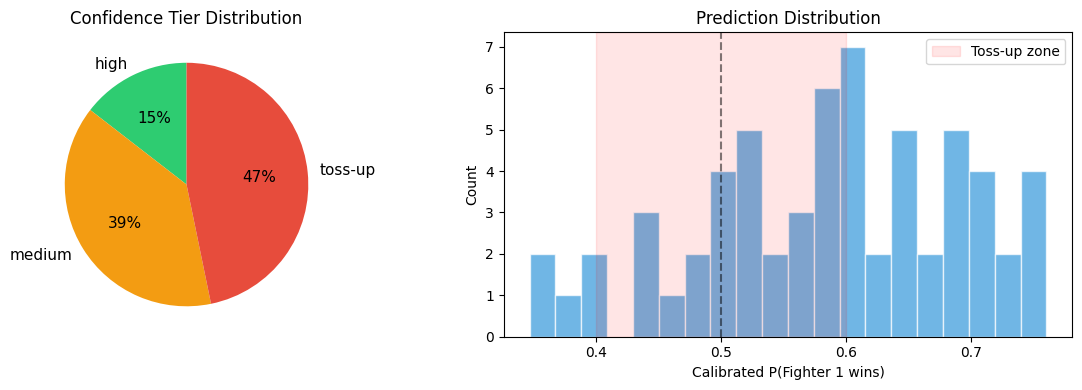


Summary: 62 fights
  high        9 (15%)
  medium      24 (39%)
  toss-up     29 (47%)


In [4]:
if HAS_PREDICTIONS:
    tier_counts = predictions["confidence_tier"].value_counts()
    tier_order = ["high", "medium", "toss-up"]
    tier_counts = tier_counts.reindex(tier_order).fillna(0)
    tier_colors = ["#2ecc71", "#f39c12", "#e74c3c"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Pie chart
    axes[0].pie(tier_counts.values, labels=tier_counts.index, colors=tier_colors,
                autopct="%1.0f%%", startangle=90, textprops={"fontsize": 11})
    axes[0].set_title("Confidence Tier Distribution")

    # Prediction histogram
    axes[1].hist(predictions["calibrated_prob_f1"], bins=20, color="#3498db",
                 alpha=0.7, edgecolor="white")
    axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)
    axes[1].axvspan(0.40, 0.60, alpha=0.1, color="red", label="Toss-up zone")
    axes[1].set_xlabel("Calibrated P(Fighter 1 wins)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Prediction Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nSummary: {len(predictions)} fights")
    for tier in tier_order:
        n = int(tier_counts.get(tier, 0))
        print(f"  {tier:<10s}  {n} ({n/len(predictions):.0%})")
else:
    print("No predictions available — skipping.")

## 5. Feature Contributions (Top Confident + Top Toss-Up Fights)

Uses SHAP to show which features drive the model's prediction for the most and least confident fights.

In [5]:
if HAS_PREDICTIONS:
    import shap
    from modeling.artifacts import load_model

    # Load model and features
    with open(PRODUCTION_MODEL) as f:
        prod = json.load(f)
    model, metadata = load_model(prod["artifact_path"])
    feature_cols = metadata["feature_cols"]

    features_df = pd.read_csv(UPCOMING_FEATURES)
    X = features_df[feature_cols]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # Identify top 3 confident and top 3 toss-up fights
    preds_sorted = predictions.copy()
    preds_sorted["confidence"] = abs(preds_sorted["calibrated_prob_f1"] - 0.5)

    top_confident = preds_sorted.nlargest(min(3, len(preds_sorted)), "confidence")
    top_tossup = preds_sorted.nsmallest(min(3, len(preds_sorted)), "confidence")

    def show_shap_for_fights(subset, title):
        print(f"\n{title}")
        print("=" * 60)
        for _, row in subset.iterrows():
            idx = predictions.index.get_loc(row.name) if row.name in predictions.index else None
            if idx is None:
                continue
            f1 = row["fighter_1_name"]
            f2 = row["fighter_2_name"]
            prob = row["calibrated_prob_f1"]
            tier = row["confidence_tier"]

            sv = shap_values[idx]
            top_idx = np.argsort(np.abs(sv))[-5:][::-1]

            print(f"\n  {f1} vs {f2}  ({prob:.1%}, {tier})")
            for i in top_idx:
                fname = feature_cols[i]
                val = float(X.iloc[idx][fname]) if not pd.isna(X.iloc[idx][fname]) else "NaN"
                print(f"    {fname:<45s}  SHAP={sv[i]:+.4f}  val={val}")

    show_shap_for_fights(top_confident, "TOP CONFIDENT FIGHTS")
    show_shap_for_fights(top_tossup, "TOP TOSS-UP FIGHTS")
else:
    print("No predictions available — skipping SHAP analysis.")


TOP CONFIDENT FIGHTS

  Alice Pereira vs Hailey Cowan  (76.0%, high)
    diff_age                                       SHAP=+0.5288  val=-13.853524982888434
    diff_career_sig_strike_defense                 SHAP=+0.1405  val=0.4530535936850851
    weight_class_rank                              SHAP=-0.1249  val=3.0
    diff_career_sig_strikes_absorbed_pm            SHAP=+0.0607  val=-0.8414634146341462
    ratio_career_wins                              SHAP=-0.0524  val=NaN

  Jacob Malkoun vs Gerald Meerschaert  (75.9%, high)
    diff_age                                       SHAP=+0.4092  val=-7.687885010266939
    diff_reach_cm                                  SHAP=-0.1150  val=-10.0
    diff_fights_per_year_last3                     SHAP=-0.0953  val=-1.852717391304348
    diff_career_control_rate                       SHAP=+0.0947  val=230.875
    diff_career_sig_strikes_absorbed_pm            SHAP=+0.0847  val=-1.1571151044196215

  Song Yadong vs Deiveson Figueiredo  (74.6%, 

## 6. Calibration Context

Overlay upcoming prediction distribution on the historical reliability diagram to see where these predictions fall relative to the model's calibration curve.

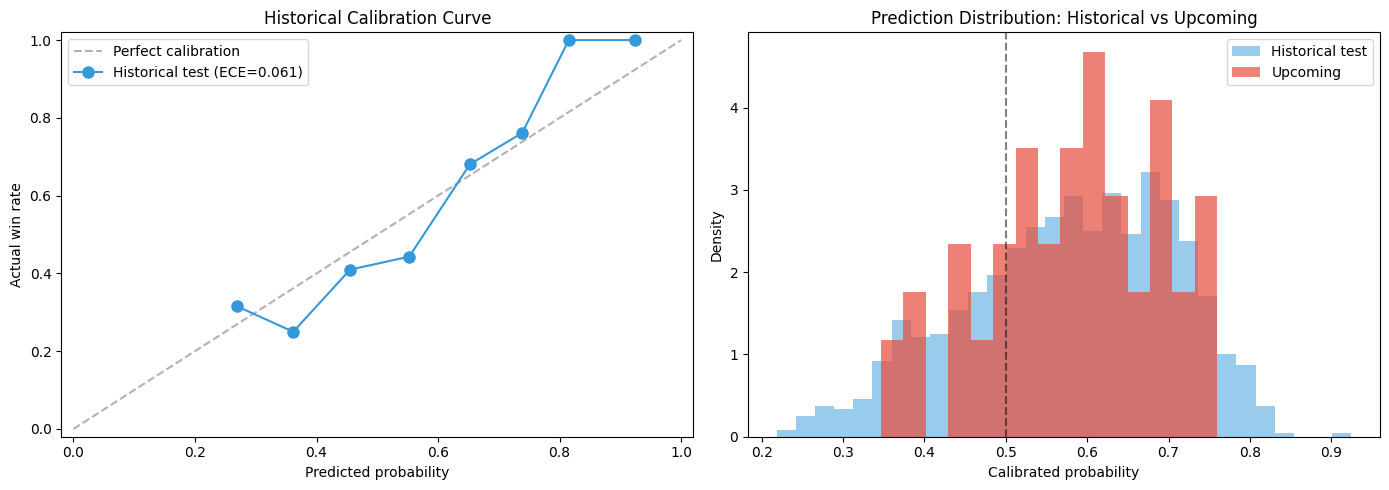

Historical test: 1017 fights, ECE=0.0614
Upcoming: 62 fights


In [6]:
# Load historical test set predictions for calibration context
from modeling.data import load_bout_data, FEATURE_COLS_V2
from features.debut_prior import compute_debut_priors, apply_debut_features

conn = get_connection()
try:
    with open(PRODUCTION_MODEL) as f:
        prod = json.load(f)
    model, metadata = load_model(prod["artifact_path"])
    feature_cols = metadata["feature_cols"]
    val_date = metadata.get("val_date", "2022-03-12")
    test_date = metadata.get("test_date", "2024-03-09")

    df = load_bout_data(conn, feature_cols=feature_cols)
    train = df[df["event_date"] < val_date]
    priors = compute_debut_priors(train)
    df = apply_debut_features(df, priors)
    test = df[df["event_date"] >= test_date].dropna(subset=["label"])

    X_test = test[feature_cols].values
    y_test = test["label"].values
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # Platt calibration on test set
    from modeling.calibrate import calibrate_platt
    val = df[(df["event_date"] >= val_date) & (df["event_date"] < test_date)].dropna(subset=["label"])
    y_prob_val = model.predict_proba(val[feature_cols].values)[:, 1]
    y_prob_test_cal = calibrate_platt(y_prob_val, val["label"].values, y_prob_test)
finally:
    conn.close()

# Plot reliability diagram
cal = assess_calibration(y_test, y_prob_test_cal)
preds_hist = [b["mean_predicted"] for b in cal["bins"] if b["count"] > 0]
actuals_hist = [b["mean_actual"] for b in cal["bins"] if b["count"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")
ax.plot(preds_hist, actuals_hist, "o-", color="#3498db", markersize=8,
        label=f"Historical test (ECE={cal['ece']:.3f})")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual win rate")
ax.set_title("Historical Calibration Curve")
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Overlay upcoming predictions on historical distribution
ax2 = axes[1]
ax2.hist(y_prob_test_cal, bins=30, alpha=0.5, color="#3498db", label="Historical test", density=True)
if HAS_PREDICTIONS:
    ax2.hist(predictions["calibrated_prob_f1"], bins=15, alpha=0.7, color="#e74c3c",
             label="Upcoming", density=True)
ax2.axvline(x=0.5, color="black", linestyle="--", alpha=0.5)
ax2.set_xlabel("Calibrated probability")
ax2.set_ylabel("Density")
ax2.set_title("Prediction Distribution: Historical vs Upcoming")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Historical test: {len(y_test)} fights, ECE={cal['ece']:.4f}")
if HAS_PREDICTIONS:
    print(f"Upcoming: {len(predictions)} fights")

## 7. Production Model Summary

In [7]:
with open(PRODUCTION_MODEL) as f:
    prod = json.load(f)

print("Production Model")
print("=" * 50)
print(f"  Model:      {prod['selected_model']}")
print(f"  Test LL:    {prod['test_log_loss']:.4f}")
print(f"  Test AUC:   {prod['test_auc']:.4f}")
print(f"  Test Brier: {prod['test_brier']:.4f}")
print(f"  Test ECE:   {prod['test_ece']:.4f}")
print(f"  Runner-up:  {prod['runner_up']}")
print(f"  Rationale:  {prod['rationale']}")
print(f"  Artifact:   {prod['artifact_path']}")

Production Model
  Model:      XGBoost (calibrated)
  Test LL:    0.6318
  Test AUC:   0.7028
  Test Brier: 0.2209
  Test ECE:   0.0614
  Runner-up:  Ensemble (stacked)
  Rationale:  XGBoost (calibrated) selected: lowest test log loss (0.6318) with post-hoc calibration improving ECE to 0.0614.
  Artifact:   /home/wlodzimierrr/ufc-data/models/xgb/20260328T221117Z
